In [1]:
from hicrep.utils import readMcool
from hicrep import hicrepSCC
from ggner_3d.cm import MCOOL_PATH_DICT_BIOREPS
import bioframe
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import tqdm
import seaborn as sns
from joblib import Parallel, delayed
import itertools


In [2]:
RESOLUTION = 50_000
H = 5
DBPMAX = 10_000_000
BDOWNSAMPLE = False

In [3]:
SCC_RESULTS = {}
SCC_RESULTS_NORM = {}

In [4]:
chromsizes = bioframe.fetch_chromsizes("hg38")
chromsizes = chromsizes[chromsizes.index.isin([f"chr{i}" for i in range(1, 23)] + ["chrX"])]
weights = chromsizes.values

In [ ]:
pairs = [
    (m1, m2, path1, path2)
    for (m1, path1), (m2, path2)
    in itertools.combinations(MCOOL_PATH_DICT_BIOREPS.items(), 2)
]

def compute_scc_pair(m1, m2, path1, path2):
    cool1, binSize1 = readMcool(path1, RESOLUTION)
    cool2, binSize2 = readMcool(path2, RESOLUTION)
    scc = hicrepSCC(cool1, cool2, H, DBPMAX, BDOWNSAMPLE)
    scc_norm = float(np.average(scc, weights=weights))
    return (m1, m2, scc, scc_norm)

results = []
for out in tqdm.tqdm(
        Parallel(n_jobs=-1, backend="loky")(delayed(compute_scc_pair)(*p) for p in pairs),
        total=len(pairs),
        desc="Computing SCCs in parallel"):
    results.append(out)

# store all results
for m1, m2, scc, scc_norm in results:
    SCC_RESULTS[(m1, m2)] = scc
    SCC_RESULTS_NORM[(m1, m2)] = scc_norm


In [6]:
import pickle
save_dir = f"/home/carlos/Clone/ggner-3d/data/scc/scc_results_bioreps_RESOLUTION{RESOLUTION}_H{H}_DBPMAX{DBPMAX}_BDOWNSAMPLE{BDOWNSAMPLE}.pkl"

In [7]:
# # save dicts as pickle
# import pickle
# save_dir = f"/home/carlos/Clone/ggner-3d/data/scc/scc_results_bioreps_RESOLUTION{RESOLUTION}_H{H}_DBPMAX{DBPMAX}_BDOWNSAMPLE{BDOWNSAMPLE}.pkl"
# with open(save_dir, "wb") as f:
#     pickle.dump({"SCC_RESULTS": SCC_RESULTS, "SCC_RESULTS_NORM": SCC_RESULTS_NORM}, f)

In [8]:
# load dicts from pickle
with open(save_dir, "rb") as f:
    data = pickle.load(f)
SCC_RESULTS = data["SCC_RESULTS"]
SCC_RESULTS_NORM = data["SCC_RESULTS_NORM"]

In [9]:
mtx = np.zeros((len(MCOOL_PATH_DICT_BIOREPS), len(MCOOL_PATH_DICT_BIOREPS)))
key_names = list(MCOOL_PATH_DICT_BIOREPS.keys())
for key in SCC_RESULTS:
    i1 = key_names.index(key[0])
    i2 = key_names.index(key[1])
    mtx[i1, i2] = SCC_RESULTS_NORM[key]
    mtx[i2, i1] = SCC_RESULTS_NORM[key]

# order key_names WT_* first, then XPC_*, then XPA_*
ordered_key_names = sorted(
    key_names,
    key=lambda x: (0 if x.startswith("WT_") else (1 if x.startswith("XPC_") else 2), x)
)

ordered_indices = [key_names.index(k) for k in ordered_key_names]
mtx_ordered = mtx[np.ix_(ordered_indices, ordered_indices)]

ordered_key_names = [k.replace("_", " ").replace("r", "Rep") for k in ordered_key_names]

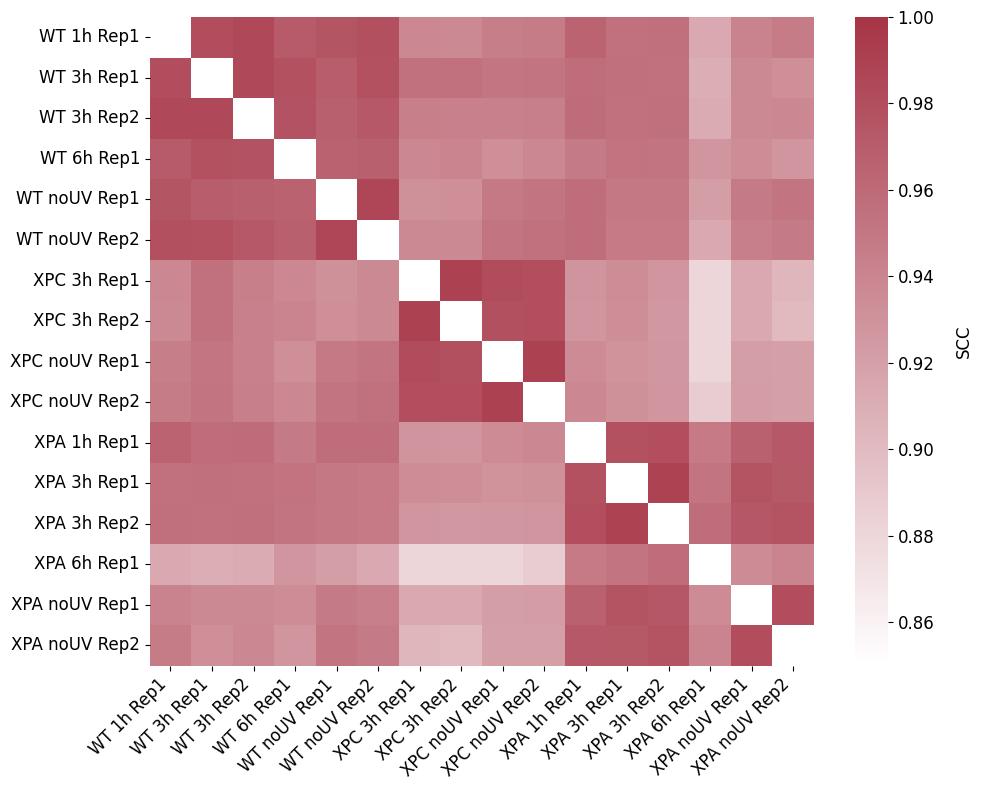

In [16]:
mask_diagonal = np.zeros_like(mtx, dtype=bool)
np.fill_diagonal(mask_diagonal, True)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))

# import linear segment colormap
from matplotlib.colors import LinearSegmentedColormap
cmp = LinearSegmentedColormap.from_list("custom_cmp", ["white", "#A63446"], N=256)
# cmp = 'viridis'
sns.heatmap(mtx_ordered, xticklabels=ordered_key_names, yticklabels=ordered_key_names,  mask=mask_diagonal, cmap=cmp, vmin=0.85, vmax=1.0, ax=ax)
# 45 degree rotation
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# add colorbar with label "SCC"
cbar = ax.collections[0].colorbar
cbar.set_label("SCC", labelpad=15, fontsize=12)

# make cbar ticks larger
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/scc_heatmap_bioreps_RESOLUTION50kb_H5_DBPMAX10Mb_BDOWNSAMPLEFalse.svg")

In [11]:
np.min(mtx[np.nonzero(mtx)])

np.float64(0.8806022798477777)